In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn import metrics

sys.path.append("../src")
from features.feature_engineering import main as import_data
from models.elo import ELO
from models.model_pipeline import main

# Helper Functions

In [2]:
def betting_simulation(df: pd.DataFrame, threshold: float) -> tuple[int, int]:
    """
    Compute the number of bets placed and bets won given a threshold.

    Args:
        df: DataFrame containing columns 'model_predictions', 'home_line', 'result'.
        threshold: Threshold for deciding when to place a bet.

    Returns:
        tuple: (bets_placed, bets_won)
    """
    bets_placed = 0
    bets_won = 0
    for row in df.itertuples():
        if row.model_predictions + threshold < -row.home_line:
            bets_placed += 1
            if row.result < row.home_line:
                bets_won += 1
        elif row.model_predictions > -row.home_line + threshold:
            bets_placed += 1
            if row.result > row.home_line:
                bets_won += 1
    return bets_placed, bets_won


def sweep_thresholds(df: pd.DataFrame, start=0, stop=3.1, step=0.1) -> pd.DataFrame:
    """
    Sweep thresholds to calculate betting accuracy and number of bets placed.

    Args:
        df: Test DataFrame.
        start: Minimum threshold.
        stop: Maximum threshold.
        step: Step size.

    Returns:
        pd.DataFrame: DataFrame with columns: 'threshold', 'accuracy', 'bets_placed'.
    """
    results = []
    for threshold in np.arange(start, stop, step):
        bets_placed, bets_won = betting_simulation(df, threshold)
        accuracy = bets_won / bets_placed if bets_placed > 0 else np.nan
        results.append(
            {"threshold": threshold, "accuracy": accuracy, "bets_placed": bets_placed}
        )
    return pd.DataFrame(results)


def evaluate_model(df: pd.DataFrame) -> dict:
    """
    Compute standard regression metrics for model and Vegas line.

    Args:
        df: DataFrame containing 'result', 'model_predictions', and 'home_line'.

    Returns:
        dict: Dictionary of RMSE, MAE, R2 for model and Vegas line.
    """
    metrics_dict = {
        "model_rmse": metrics.root_mean_squared_error(df["result"], df["model_predictions"]),
        "model_mae": metrics.mean_absolute_error(df["result"], df["model_predictions"]),
        "model_r2": metrics.r2_score(df["result"], df["model_predictions"]),
        "vegas_rmse": metrics.root_mean_squared_error(df["result"], -df["home_line"]),
        "vegas_mae": metrics.mean_absolute_error(df["result"], -df["home_line"]),
        "vegas_r2": metrics.r2_score(df["result"], -df["home_line"]),
    }
    return metrics_dict


def plot_pipeline_results(
    df: pd.DataFrame, results: pd.DataFrame, model, x_train: pd.DataFrame
):
    """
    Plot model evaluation results.

    Args:
        df: Test dataframe containing 'result', 'model_predictions', and 'home_line'.
        results: DataFrame from sweep_thresholds helper function.
        model: Trained model for SHAP analysis.
        x_train: Training feature matrix for SHAP computation.
    """
    # --- Threshold plots ---
    plt.figure(figsize=(8, 4))

    # Accuracy vs Threshold
    plt.subplot(1, 2, 1)
    plt.plot(results["threshold"], results["accuracy"])
    plt.xlabel("Model edge")
    plt.ylabel("Accuracy")
    plt.title("Betting Accuracy vs Threshold")

    # Bets placed vs Threshold
    plt.subplot(1, 2, 2)
    plt.plot(results["threshold"], results["bets_placed"])
    plt.xlabel("Model edge")
    plt.ylabel("Bets placed")
    plt.title("Bets Placed vs Threshold")

    plt.tight_layout()
    plt.show()

    # --- SHAP summary plot ---
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x_train)
    shap.summary_plot(
        shap_values,
        x_train,
        max_display=20,
        plot_type="violin",
        show=True,
        plot_size=[8, 6]
    )

# Import Data

In [3]:
historical_elos = pd.read_csv("../data/external/historical_elos.csv")
data = import_data(2010, 2024, span=5)
data = ELO(data, historical_elos).data

features = [
    col for col in data.columns if col not in [
        "game_id",
        "season",
        "week",
        "home_team",
        "away_team",
        "result",
        "roof",
        "surface",
        "attendance",
        "home_line",
        "over_under",
    ]
]

data.head()

,game_id,season,week,home_team,away_team,result,home_line,over_under,roof,surface,...,ydsnet_mean_adv_away,tackled_for_loss_sum_adv_home,tackled_for_loss_sum_adv_away,yards_after_catch_sum_adv_home,yards_after_catch_sum_adv_away,home_elo,away_elo,home_elo_prob,away_elo_prob,elo_diff
0,20110908_nor_gnb,2011,1,gnb,nor,8.0,-5.0,48.0,outdoors,grass,...,6.686245,-0.107843,0.000000,8.970588,21.147059,1661.483,1562.051,0.720420,0.279580,99.432
1,20110911_phi_ram,2011,1,ram,phi,-18.0,4.0,44.5,indoors,turf,...,1.393940,-0.446078,-0.855392,6.737745,6.928922,1416.520,1551.734,0.400307,0.599693,-135.214
2,20110911_clt_htx,2011,1,htx,clt,27.0,-9.0,44.0,outdoors,grass,...,1.924899,0.213235,0.017157,15.774510,-6.669118,1478.396,1567.700,0.465081,0.534919,-89.304
3,20110911_oti_jax,2011,1,jax,oti,2.0,1.5,38.0,outdoors,grass,...,-6.736981,-0.958333,0.333333,-21.541667,-32.250000,1474.460,1471.892,0.596031,0.403969,2.568
4,20110911_pit_rav,2011,1,rav,pit,28.0,-1.5,37.0,outdoors,turf,...,2.215047,0.325536,0.561404,8.651072,3.403509,1612.017,1606.563,0.600024,0.399976,5.454


# Direct Model

In [4]:
df_train, df_test, model, best_params = main(
    data=data,
    train_seasons=list(range(2011, 2024)),
    test_seasons=[2024],
    features=features,
    model_class="XGB",
    n_trials=50,
    target_type="direct",
    baseline_col=None
)

[I 2025-10-06 16:03:07,899] A new study created in memory with name: no-name-ce65c2dc-ca3c-4320-9182-c2806848e1ea
[I 2025-10-06 16:03:10,462] Trial 0 finished with value: 13.35945192436106 and parameters: {'max_depth': 6, 'min_child_weight': 11, 'subsample': 0.5231470688953306, 'colsample_bynode': 0.6441446829415449, 'reg_lambda': 0.04040599339540244, 'learning_rate': 0.06477731485592268}. Best is trial 0 with value: 13.35945192436106.
[I 2025-10-06 16:03:15,746] Trial 1 finished with value: 13.350518535681976 and parameters: {'max_depth': 10, 'min_child_weight': 10, 'subsample': 0.7345774249541387, 'colsample_bynode': 0.9019883251375218, 'reg_lambda': 0.034564692524468754, 'learning_rate': 0.06635856545355674}. Best is trial 1 with value: 13.350518535681976.
[I 2025-10-06 16:03:23,525] Trial 2 finished with value: 13.331422835241234 and parameters: {'max_depth': 7, 'min_child_weight': 4, 'subsample': 0.9323785449687272, 'colsample_bynode': 0.8858096439597616, 'reg_lambda': 0.056373215

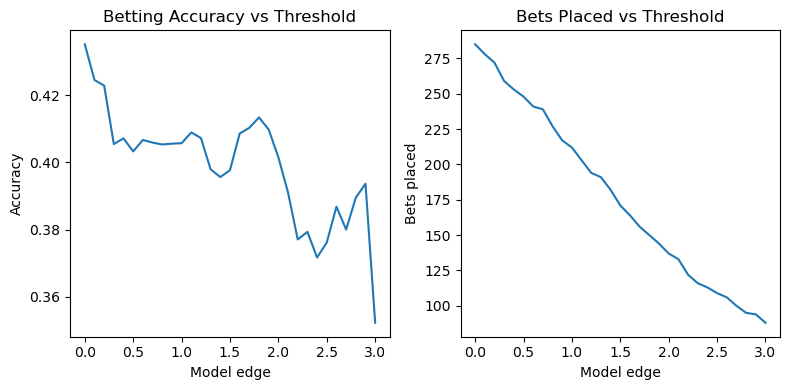

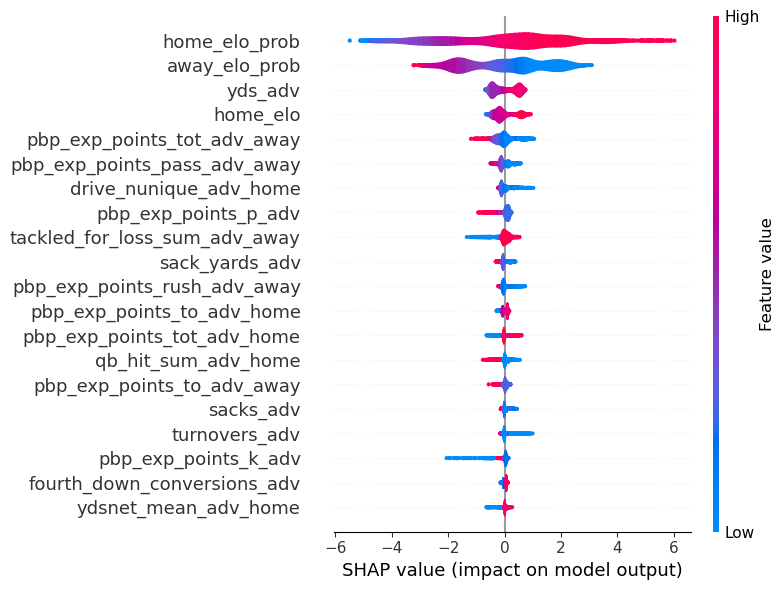

{'model_rmse': 13.026528407205221,
 'model_mae': 9.94963674806712,
 'model_r2': 0.1802700752667784,
 'vegas_rmse': 12.674224430405227,
 'vegas_mae': 9.829824561403509,
 'vegas_r2': 0.22400987581689857}

In [5]:
results = sweep_thresholds(df_test)
plot_pipeline_results(df_test, results, model, df_train[features])
evaluate_model(df_test)

# Residual Model

In [6]:
df_train, df_test, model, best_params = main(
    data=data,
    train_seasons=list(range(2011, 2024)),
    test_seasons=[2024],
    features=features,
    model_class="XGB",
    n_trials=50,
    target_type="residual",
    baseline_col="home_line"
)

[I 2025-10-06 16:07:26,250] A new study created in memory with name: no-name-cb13ebbf-8bcf-4e2a-a238-8c5b564c4f77
[I 2025-10-06 16:07:31,886] Trial 0 finished with value: 14.94092161969907 and parameters: {'max_depth': 9, 'min_child_weight': 2, 'subsample': 0.5656909351238117, 'colsample_bynode': 0.5005022036384906, 'reg_lambda': 0.008411735747234441, 'learning_rate': 0.13942653915321487}. Best is trial 0 with value: 14.94092161969907.
[I 2025-10-06 16:07:43,490] Trial 1 finished with value: 14.476398930566594 and parameters: {'max_depth': 8, 'min_child_weight': 16, 'subsample': 0.9492870133275388, 'colsample_bynode': 0.728040337121604, 'reg_lambda': 21.80538343368129, 'learning_rate': 0.016423653665792397}. Best is trial 1 with value: 14.476398930566594.
[I 2025-10-06 16:07:45,800] Trial 2 finished with value: 14.974849888517362 and parameters: {'max_depth': 12, 'min_child_weight': 19, 'subsample': 0.5564110900395963, 'colsample_bynode': 0.5240630339101497, 'reg_lambda': 0.01655968558

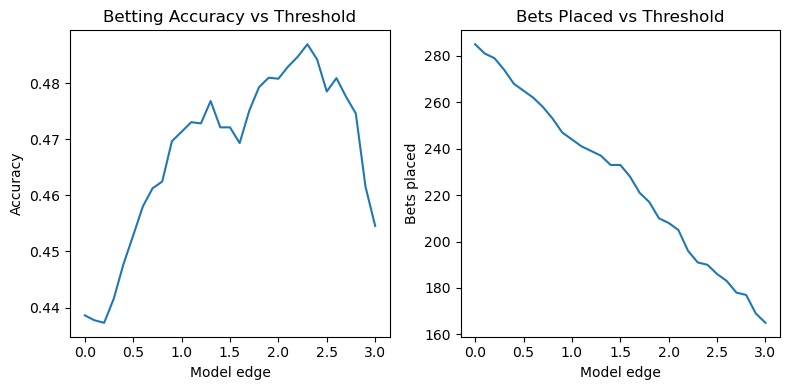

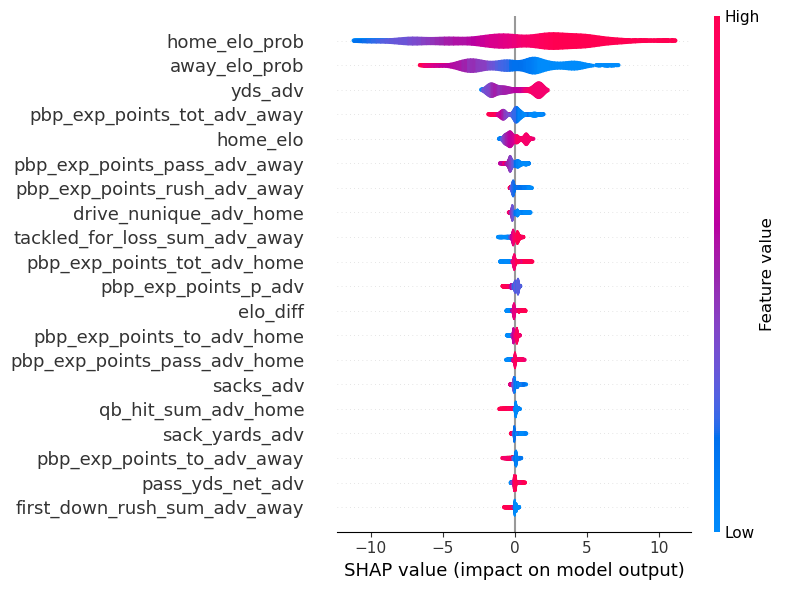

{'model_rmse': 14.11038111670022,
 'model_mae': 10.738516551674458,
 'model_r2': 0.038186439371491465,
 'vegas_rmse': 12.674224430405227,
 'vegas_mae': 9.829824561403509,
 'vegas_r2': 0.22400987581689857}

In [7]:
results = sweep_thresholds(df_test)
plot_pipeline_results(df_test, results, model, df_train[features])
evaluate_model(df_test)